In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset


2026-06-30 14:56:25.867124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782831386.281886      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782831386.395975      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782831387.350124      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782831387.350167      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782831387.350170      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [25]:
# Paths and constants

# IMG_SIZE = 160*16 because that's what EfficientNetB0 expects as input.
# BATCH = how many images the model looks at per training step.

from pathlib import Path

DATASET_DIR = Path(path)

TRAIN_DIR = DATASET_DIR / "Training"
TEST_DIR  = DATASET_DIR / "Testing"

OUTPUT_DIR = Path("/kaggle/working/outcome")
OUTPUT_DIR.mkdir(exist_ok=True)

IMG_SIZE = (160, 160)
BATCH = 8
SEED = 42


print("Training:", TRAIN_DIR)
print("Testing :", TEST_DIR)

Training: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Testing : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing


In [26]:
import os
print(os.listdir(TRAIN_DIR))

['pituitary', 'notumor', 'meningioma', 'glioma']


In [27]:
import os

print("TRAIN DIR CONTENTS:")
print(os.listdir(TRAIN_DIR))

print("\nTEST DIR CONTENTS:")
print(os.listdir(TEST_DIR))

TRAIN DIR CONTENTS:
['pituitary', 'notumor', 'meningioma', 'glioma']

TEST DIR CONTENTS:
['pituitary', 'notumor', 'meningioma', 'glioma']


In [28]:
# Data loading (no manual rescaling — EfficientNetB0 handles its
# own preprocessing internally, expects raw 0-255 pixel values)

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="categorical", validation_split=0.15,
    subset="training", seed=SEED
)
val_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="categorical", validation_split=0.15,
    subset="validation", seed=SEED
)
test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="categorical", shuffle=False
)

class_names = train_data.class_names
print("Class names:", class_names)
print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Test batches: {len(test_data)}")

Found 5600 files belonging to 4 classes.
Using 4760 files for training.


I0000 00:00:1782833325.021434      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782833325.027596      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training batches: 595
Validation batches: 105
Test batches: 200


In [29]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/masoudnickparvar
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/notumor
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/meningioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/glioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/pituitary
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/notumor
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/meningioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma
/kaggle/input/notebooks
/kaggle/input/notebooks/samiwadho
/kag

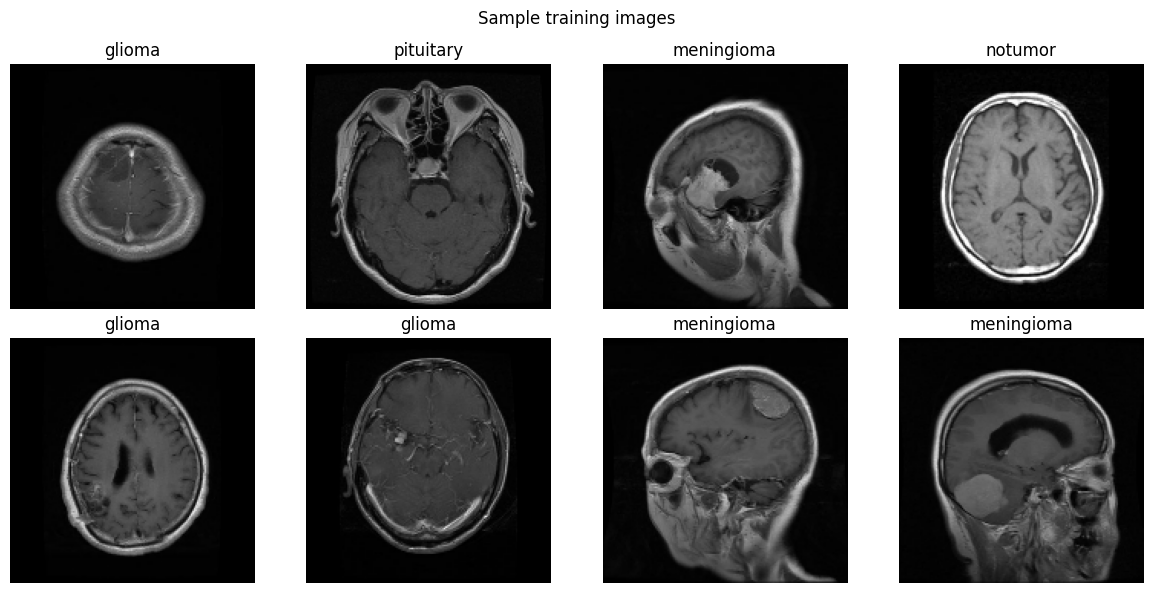

In [30]:
# CELL 4 Visualize a few sample images

from PIL import Image
sample_imgs, sample_labels = next(iter(train_data))
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_imgs[i].numpy().astype("uint8"))
    label_idx = np.argmax(sample_labels[i])
    plt.title(class_names[label_idx])
    plt.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "sample_training_images.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [31]:
# Build the model: EfficientNetB0 transfer learning
# We load EfficientNetB0 pretrained on ImageNet (1.4M general photos).
# Even though MRI scans look nothing like ImageNet photos, the EARLY
# layers of any CNN learn generic features (edges, textures, gradients)
# that transfer reasonably well. We freeze those layers (trainable=False)
# so we don't destroy that pretrained knowledge, and we only train a new,
# small classification head on top, specific to our 4 tumor classes.
#
base_model = EfficientNetB0(
    include_top=False,        # exclude ImageNet's original 1000-class head
    weights= "imagenet",
    input_shape=(160, 160, 3)
)
base_model.trainable = False  # freeze pretrained layers for now

x = GlobalAveragePooling2D()(base_model.output)  # collapse feature maps to a vector
x = Dropout(0.3)(x)                               # randomly drop 30% of connections -> reduces overfitting
x = Dense(128, activation="relu")(x)              # learn task-specific combinations
output = Dense(4, activation="softmax")(x)        # 4 probabilities, one per class

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 160, 160,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 160, 160,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 161, 161,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 80, 80,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 80, 80,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 80, 80,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 80, 80,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 80, 80,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 80, 80,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 80, 80,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 80, 80,    │        512 │ block1a_se_excit

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [32]:
# Train the model

early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=200,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/200


I0000 00:00:1782833691.419847     124 service.cc:152] XLA service 0x7f7c780019a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782833691.419909     124 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782833691.419915     124 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782833693.850379     124 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-30 15:35:01.840942: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 15:35:01.973395: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 15:35:02.286123: E external/local_xl

595/595 ━━━━━━━━━━━━━━━━━━━━ 47s 29ms/step - accuracy: 0.8170 - loss: 0.4844 - val_accuracy: 0.8810 - val_loss: 0.3036 - learning_rate: 0.0010
Epoch 2/200
595/595 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8744 - loss: 0.3320 - val_accuracy: 0.9119 - val_loss: 0.2329 - learning_rate: 0.0010
Epoch 3/200
595/595 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8996 - loss: 0.2672 - val_accuracy: 0.9024 - val_loss: 0.2353 - learning_rate: 0.0010
Epoch 4/200
595/595 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9099 - loss: 0.2357 - val_accuracy: 0.9310 - val_loss: 0.1899 - learning_rate: 0.0010
Epoch 5/200
595/595 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9181 - loss: 0.2054 - val_accuracy: 0.9369 - val_loss: 0.1982 - learning_rate: 0.0010
Epoch 6/200
595/595 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9300 - loss: 0.1830 - val_accuracy: 0.9179 - val_loss: 0.2182 - learning_rate: 0.0010
Epoch 7/200
595/595 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9447 - loss: 0.1487

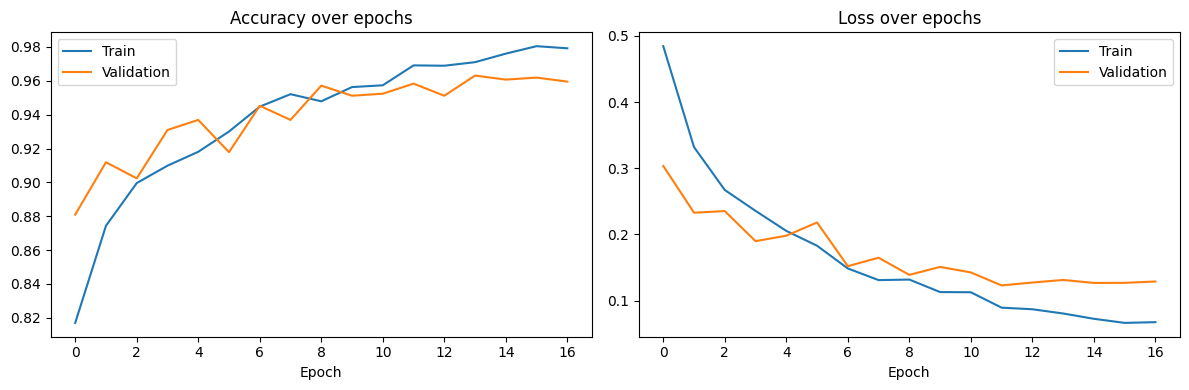

In [33]:
# Plot training curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [34]:
# Evaluate on the held-out test set

test_loss, test_acc = model.evaluate(test_data)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9137 - loss: 0.4558

Final Test Accuracy: 0.9137
Final Test Loss: 0.4558


200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.71      0.82       400
  meningioma       0.82      0.95      0.88       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.98      0.99      0.98       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600



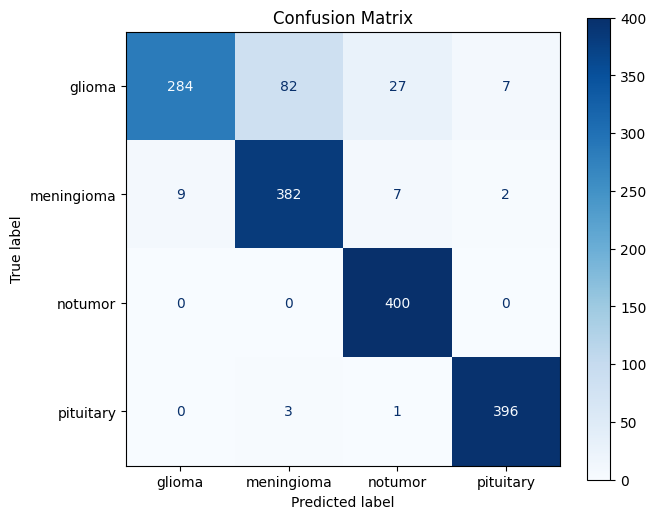

In [36]:
# CELL 9  Confusion matrix and per-class report

preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

# Extract true labels by iterating the dataset (no .classes attribute
# on tf.data.Dataset, unlike the older ImageDataGenerator)
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_data])

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix")
plt.savefig(OUTPUT_DIR / "confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [40]:
# Grad-CAM implementation

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)               # how much each feature matters
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))     # average importance per channel
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]   # weighted combination
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)  # normalize 0-1
    return heatmap.numpy(), class_idx.numpy()


def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    overlayed = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    return overlayed

In [41]:
# Find the correct last conv layer name (run this if Cell 12 errors)

for layer in model.layers[-10:]:
    print(layer.name, "-", layer.__class__.__name__)

block7a_se_excite - Multiply
block7a_project_conv - Conv2D
block7a_project_bn - BatchNormalization
top_conv - Conv2D
top_bn - BatchNormalization
top_activation - Activation
global_average_pooling2d - GlobalAveragePooling2D
dropout - Dropout
dense - Dense
dense_1 - Dense


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)


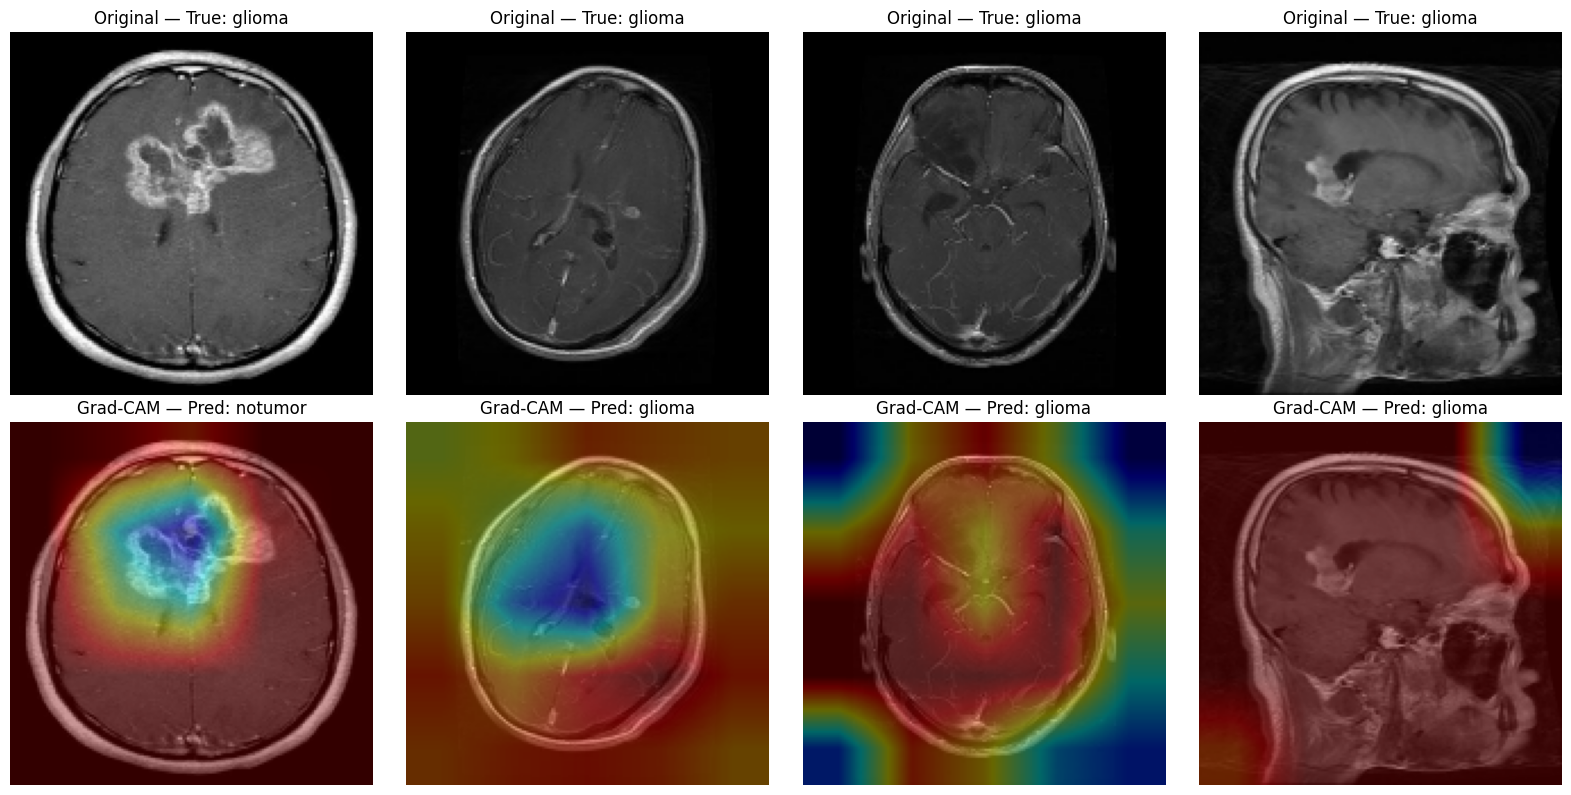

In [42]:
# Runing Grad-CAM on sample test images

LAST_CONV_LAYER = "top_conv"  # change this if Cell 11 showed a different name

sample_batch, sample_labels = next(iter(test_data))
sample_batch = sample_batch.numpy()
sample_labels = sample_labels.numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img_array = np.expand_dims(sample_batch[i], axis=0)
    heatmap, pred_class = get_gradcam_heatmap(model, img_array, LAST_CONV_LAYER)

    # sample_batch is already 0-255 (no rescale layer in this version of
    # Cell 3), so just cast to uint8 for display — no *255 needed here.
    original_img = np.uint8(sample_batch[i])
    overlayed = overlay_heatmap(original_img, heatmap)

    true_class = class_names[np.argmax(sample_labels[i])]
    pred_label = class_names[pred_class]

    axes[0, i].imshow(original_img)
    axes[0, i].set_title(f"Original — True: {true_class}")
    axes[0, i].axis("off")

    axes[1, i].imshow(overlayed)
    axes[1, i].set_title(f"Grad-CAM — Pred: {pred_label}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "gradcam_results.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Total misclassified: 138 out of 1600 test images

Most common confusion pairs (true -> predicted):
  glioma -> meningioma: 82 times
  glioma -> notumor: 27 times
  meningioma -> glioma: 9 times
  glioma -> pituitary: 7 times
  meningioma -> notumor: 7 times


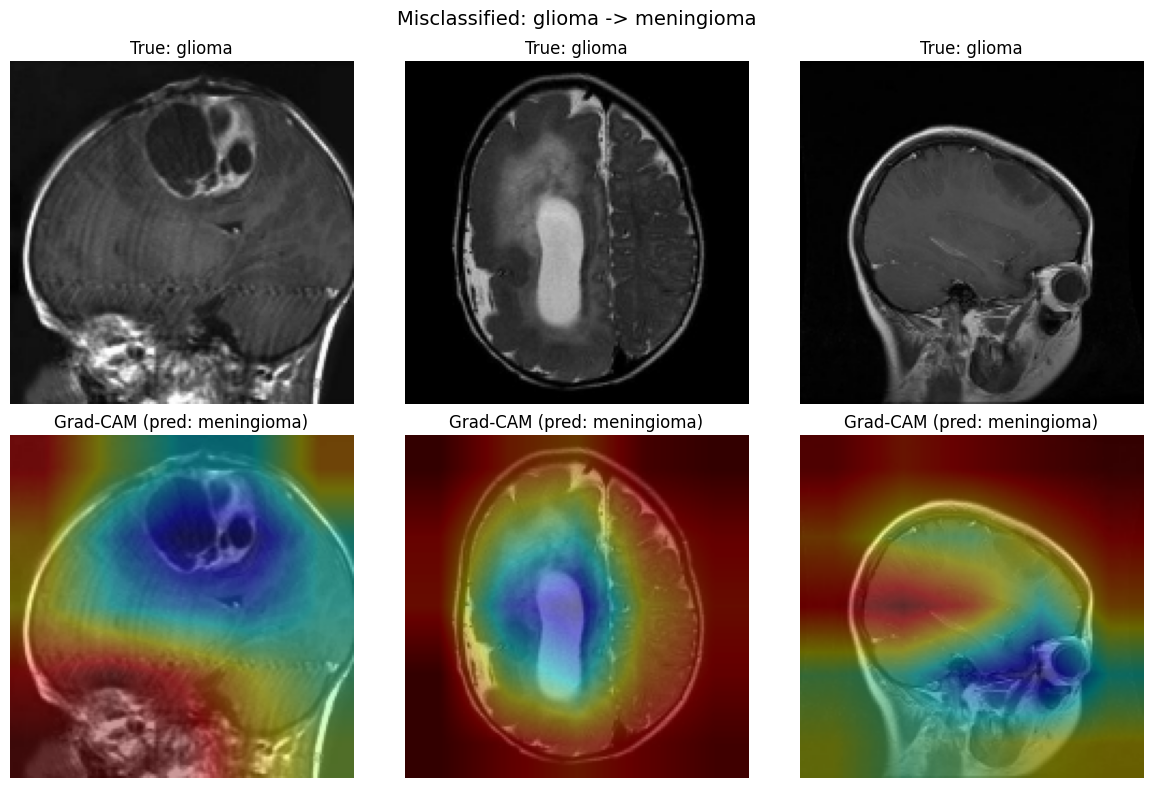

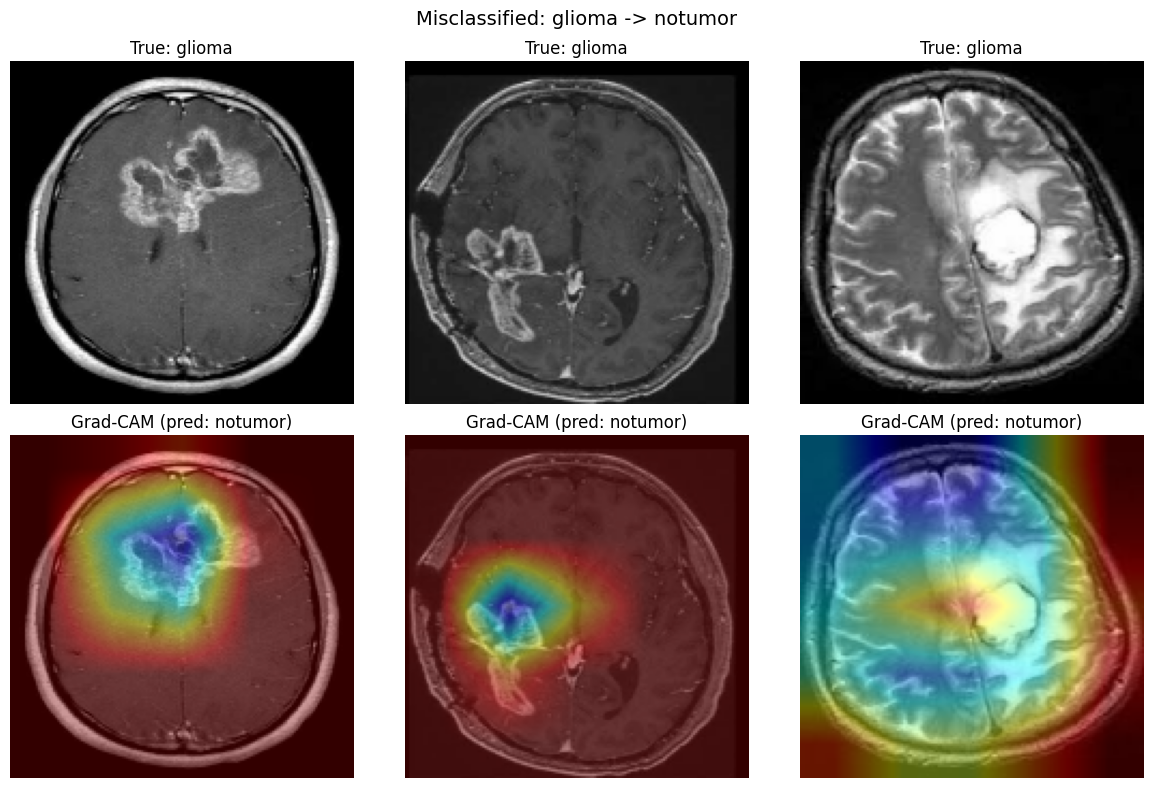

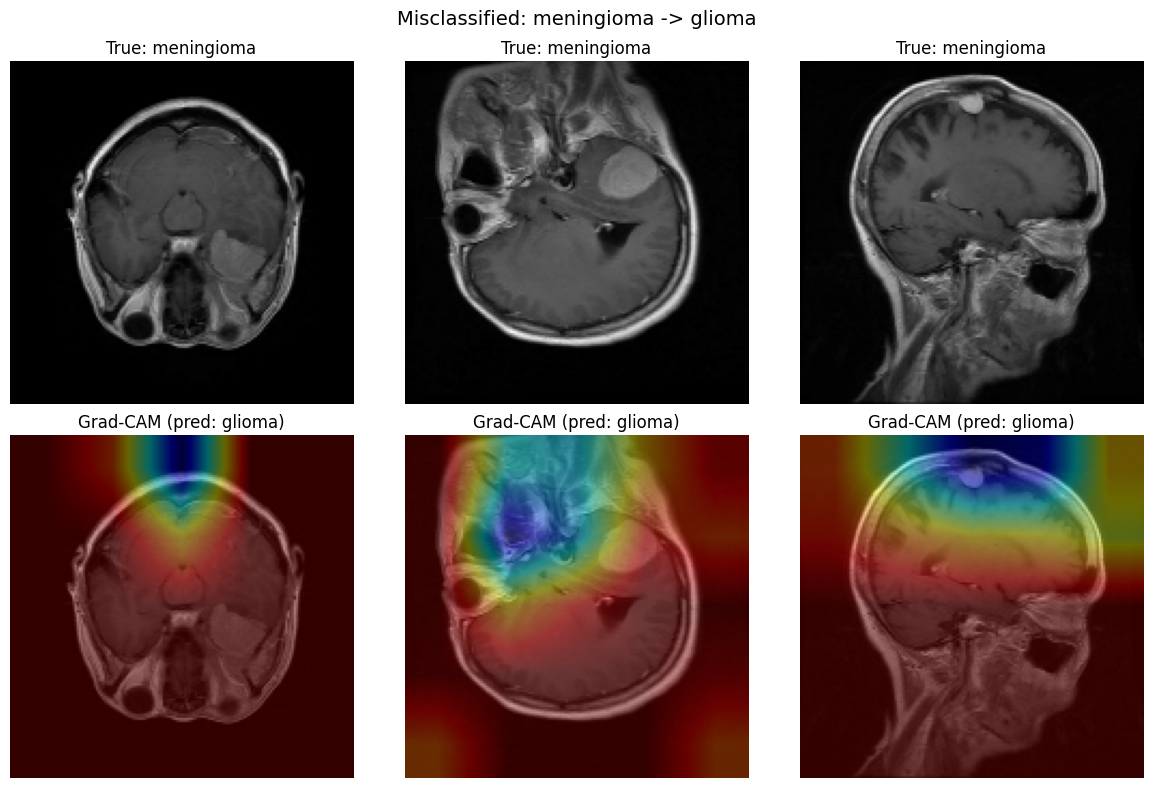

In [44]:
#  Misclassification deep-dive (Objectives 3 & 4)
# MISCLASSIFIED INDICES

wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} out of {len(y_true)} test images\n")

from collections import Counter
confusion_pairs = Counter()
for i in wrong_idx:
    pair = (class_names[y_true[i]], class_names[y_pred[i]])
    confusion_pairs[pair] += 1

print("Most common confusion pairs (true -> predicted):")
for pair, count in confusion_pairs.most_common(5):
    print(f"  {pair[0]} -> {pair[1]}: {count} times")

# Collecting all test images into one array, same order as y_true/y_pred
# (No filepaths exist for this dataset type, so we use the actual pixel
# arrays already flowing through test_data instead of reloading from disk.)
all_test_images = np.concatenate([images.numpy() for images, _ in test_data], axis=0)

# Objective 3 & 4: Grad-CAM on the actual misclassified images
top_pairs = [pair for pair, _ in confusion_pairs.most_common(3)]

for true_cls, pred_cls in top_pairs:
    example_idx = [
        i for i in wrong_idx
        if class_names[y_true[i]] == true_cls and class_names[y_pred[i]] == pred_cls
    ][:3]

    if not example_idx:
        continue

    fig, axes = plt.subplots(2, len(example_idx), figsize=(4 * len(example_idx), 8))
    if len(example_idx) == 1:
        axes = axes.reshape(2, 1)

    for col, idx in enumerate(example_idx):
        img = all_test_images[idx]                  # already 0-255, matches Cell 3
        img_array = np.expand_dims(img, axis=0)

        heatmap, _ = get_gradcam_heatmap(model, img_array, LAST_CONV_LAYER)
        overlayed = overlay_heatmap(np.uint8(img), heatmap)

        axes[0, col].imshow(np.uint8(img))
        axes[0, col].set_title(f"True: {true_cls}")
        axes[0, col].axis("off")

        axes[1, col].imshow(overlayed)
        axes[1, col].set_title(f"Grad-CAM (pred: {pred_cls})")
        axes[1, col].axis("off")

    plt.suptitle(f"Misclassified: {true_cls} -> {pred_cls}", fontsize=14)
    plt.tight_layout()
    plt.savefig(
    OUTPUT_DIR / "misclassified_samples.png",
    dpi=300,
    bbox_inches="tight")
    plt.show()

In [45]:
# Save the trained model

model.save("brain_tumor_efficientnetb0.keras")
print("Model saved as brain_tumor_efficientnetb0.keras")

Model saved as brain_tumor_efficientnetb0.keras
